# STATE HP sweep on PBMC — MI curves

One line per HP trial, x = quality (log), y = MI per signal.

In [1]:
# Gather results by walking the actual on-disk layout:
#   hp_tunning/hp_trial_XX/<size>/<quality>/
#     ├─ config.json                                               (HP params + metadata; written pre-train)
#     ├─ result.json                                               (post-run; status=ok|error, train_time_s)
#     ├─ checkpoints/**/version_*/metrics.csv                      (Lightning train/val loss curves)
#     └─ MI/<seed>/Y_<signal>_<quality>/lmi_mutual_information.txt
#
# The hp_trial_XX.yaml index files are only written once the whole sweep finishes,
# so we walk hp_trial_* directly and read config.json for HP params.
# Per-step training and validation loss curves come from Lightning's CSVLogger.
# The resulting DataFrame holds scalars; the raw curves live in the CURVES dict.
import json
import re
from pathlib import Path

import pandas as pd

OUTPUT_DIR = Path('/home/igor/noise_scaling/data/other/hp_tunning')
MI_SEED = 42  # first seed emitted by latentmi

def _num(s: str):
    try: return int(s)
    except ValueError:
        try: return float(s)
        except ValueError: return s

def _read_metrics(leaf: Path):
    """Return (train_df, val_df) from Lightning's metrics.csv, or (None, None).

    train_df: columns [step, train_loss]; val_df: columns [step, val_loss].
    Rows without the corresponding loss value are dropped and each is sorted by step.
    """
    matches = sorted(leaf.glob('checkpoints/**/version_*/metrics.csv'))
    if not matches:
        return None, None
    m = pd.read_csv(matches[0])
    tcol, vcol = 'trainer/train_loss', 'validation/val_loss'
    train_df = (m.dropna(subset=[tcol])[['step', tcol]].rename(columns={tcol: 'train_loss'})
                 .sort_values('step').reset_index(drop=True)) if tcol in m.columns else None
    val_df   = (m.dropna(subset=[vcol])[['step', vcol]].rename(columns={vcol: 'val_loss'})
                 .sort_values('step').reset_index(drop=True)) if vcol in m.columns else None
    return train_df, val_df

rows = []
CURVES: dict = {}  # (trial_id, size, quality) -> {'train': DataFrame, 'val': DataFrame}

for trial_dir in sorted(OUTPUT_DIR.glob('hp_trial_*')):
    if not trial_dir.is_dir():
        continue
    m = re.match(r'hp_trial_(\d+)$', trial_dir.name)
    if not m:
        continue
    trial_id = int(m.group(1))

    for size_dir in sorted(p for p in trial_dir.iterdir() if p.is_dir()):
        size_val = _num(size_dir.name)
        if not isinstance(size_val, (int, float)):
            continue
        for q_dir in sorted(p for p in size_dir.iterdir() if p.is_dir()):
            quality_val = _num(q_dir.name)
            if not isinstance(quality_val, (int, float)):
                continue

            cfg_path = q_dir / 'config.json'
            cfg = json.loads(cfg_path.read_text()) if cfg_path.exists() else {}
            row = {
                'trial_id': trial_id,
                'trial_name': cfg.get('trial_name', f'hp_trial_{trial_id:02d}'),
                'size': int(size_val),
                'quality': float(quality_val),
                **(cfg.get('swept_params') or {}),
            }

            res_path = q_dir / 'result.json'
            if res_path.exists():
                try:
                    res = json.loads(res_path.read_text())
                    row['status'] = res.get('status', 'unknown')
                    row['train_time_s'] = res.get('train_time_s')
                except json.JSONDecodeError:
                    row['status'] = 'corrupt'
            else:
                row['status'] = 'pending'

            # Training / validation loss curves from Lightning's metrics.csv.
            # Final values go into df; full curves live in CURVES for plotting.
            train_df, val_df = _read_metrics(q_dir)
            if train_df is not None and len(train_df):
                row['train_loss_final'] = float(train_df['train_loss'].iloc[-1])
                row['n_train_steps'] = int(train_df['step'].iloc[-1])
            if val_df is not None and len(val_df):
                row['val_loss_final'] = float(val_df['val_loss'].iloc[-1])
            CURVES[(trial_id, int(size_val), float(quality_val))] = {
                'train': train_df, 'val': val_df,
            }

            mi_root = q_dir / 'MI' / str(MI_SEED)
            if mi_root.is_dir():
                for sig_dir in filter(Path.is_dir, mi_root.iterdir()):
                    # Y_<signal>_<quality-as-text>  ->  strip the trailing quality suffix
                    sm = re.match(r'Y_(.+)_[0-9][0-9_.]*$', sig_dir.name)
                    signal = sm.group(1) if sm else sig_dir.name
                    f = sig_dir / 'lmi_mutual_information.txt'
                    if f.exists():
                        try: row[f'mi_{signal}'] = float(f.read_text().strip())
                        except ValueError: pass
            rows.append(row)

df = pd.DataFrame(rows)
if len(df):
    df = df.sort_values(['trial_id', 'size', 'quality']).reset_index(drop=True)
mi_cols_found = sorted(c for c in df.columns if c.startswith('mi_'))
n_trials = df['trial_id'].nunique() if len(df) else 0
n_ok = int((df['status'] == 'ok').sum()) if 'status' in df.columns else 0
n_curves = sum(1 for v in CURVES.values() if v['train'] is not None and len(v['train']))
print(f'{len(df)} rows across {n_trials} trials  ok={n_ok}  curves={n_curves}  mi_cols={mi_cols_found}')
df

160 rows across 16 trials  ok=160  curves=160  mi_cols=['mi_celltype.l3', 'mi_protein_counts']


,trial_id,trial_name,size,quality,dropout,batch_size,max_lr,weight_decay,status,train_time_s,train_loss_final,n_train_steps,val_loss_final,mi_celltype.l3,mi_protein_counts
0,0,hp_trial_00_100000_0.0012346,100000,0.001235,0.3,64,0.0001,0.1000,ok,5334.567772,8.982543,3119,5.985038,0.22919,0.31068
1,0,hp_trial_00_100000_0.0025982,100000,0.002598,0.3,64,0.0001,0.1000,ok,349.916058,17.964203,9,17.248381,-0.01117,-0.00174
2,0,hp_trial_00_100000_0.0054682,100000,0.005468,0.3,64,0.0001,0.1000,ok,4637.131062,13.083869,3135,11.754370,1.04089,1.08539
3,0,hp_trial_00_100000_0.0115083,100000,0.011508,0.3,64,0.0001,0.1000,ok,4166.887816,14.059572,3135,13.938963,1.25358,1.23527
4,0,hp_trial_00_100000_0.02422,100000,0.024220,0.3,64,0.0001,0.1000,ok,341.463720,24.390783,9,24.486446,0.05567,0.06013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,15,hp_trial_15_100000_0.050973,100000,0.050973,0.0,32,0.0010,0.0001,ok,4982.728262,14.729032,6255,13.477683,0.03100,0.05728
156,15,hp_trial_15_100000_0.1072766,100000,0.107277,0.0,32,0.0010,0.0001,ok,5606.108599,11.763534,6255,11.476081,0.31496,0.39818
157,15,hp_trial_15_100000_0.225772,100000,0.225772,0.0,32,0.0010,0.0001,ok,290.184000,33.453087,9,27.809307,0.34961,0.43737
158,15,hp_trial_15_100000_0.4751547,100000,0.475155,0.0,32,0.0010,0.0001,ok,358.173163,64.415924,9,55.487907,0.37356,0.46113


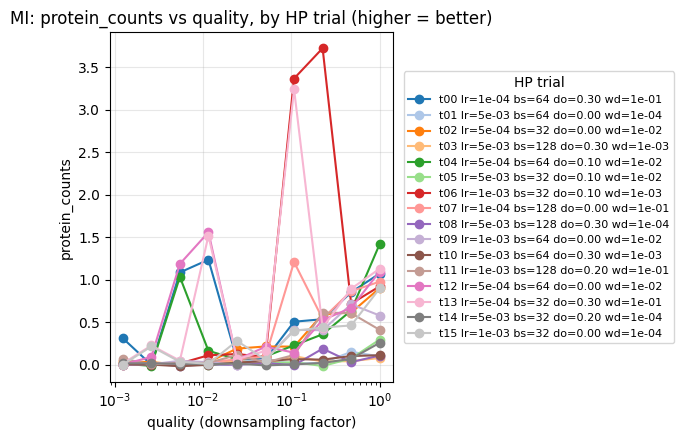

In [2]:
# MI curve for protein_counts only: one line per HP trial, x = quality (log), y = MI.
import matplotlib.pyplot as plt

mi_col = 'mi_protein_counts'
if mi_col not in df.columns:
    print(f'{mi_col} not found — nothing to plot.')
else:
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    trial_ids = sorted(df['trial_id'].unique())
    cmap = plt.get_cmap('tab20' if len(trial_ids) > 10 else 'tab10')

    for i, tid in enumerate(trial_ids):
        sub = df[df['trial_id'] == tid].sort_values('quality')
        sub = sub[sub[mi_col].notna()]
        if sub.empty:
            continue
        cfg = sub.iloc[0]
        label = (f"t{int(tid):02d} "
                 f"lr={cfg['max_lr']:.0e} bs={int(cfg['batch_size'])} "
                 f"do={cfg['dropout']:.2f} wd={cfg['weight_decay']:.0e}")
        ax.plot(sub['quality'].values, sub[mi_col].values,
                marker='o', linewidth=1.5, color=cmap(i % cmap.N), label=label)

    ax.set_xscale('log')
    ax.set_xlabel('quality (downsampling factor)')
    ax.set_ylabel('protein_counts')
    ax.set_title('MI: protein_counts vs quality, by HP trial (higher = better)')
    ax.grid(alpha=0.3)
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8, title='HP trial')
    plt.tight_layout()
    plt.show()

In [3]:
# Original-work baselines: load MI for the per-algorithm runs that live alongside the HP sweep.
# Layout:  data/PBMC/<size>/<quality>/results/<algo>/model/MI/<seed>/Y_<signal>_<quality>/lmi_mutual_information.txt
# We pull size=100000, seed=42 across all qualities for every algorithm that has data for the same signal.
import re
from pathlib import Path

import pandas as pd

ORIG_ROOT = Path('/home/igor/noise_scaling/data/PBMC')
ORIG_SIZE = 100000
ORIG_SEED = 42
ORIG_SIGNAL = 'protein_counts'  # match mi_col in the HP-sweep plot above

orig_rows = []
size_dir = ORIG_ROOT / str(ORIG_SIZE)
for q_dir in sorted(p for p in size_dir.iterdir() if p.is_dir()):
    try:
        quality = float(q_dir.name)
    except ValueError:
        continue
    results_dir = q_dir / 'results'
    if not results_dir.is_dir():
        continue
    for algo_dir in sorted(p for p in results_dir.iterdir() if p.is_dir()):
        algo = algo_dir.name
        if algo == 'TunableState':
            continue  # that's the HP sweep, already plotted
        mi_root = algo_dir / 'model' / 'MI' / str(ORIG_SEED)
        if not mi_root.is_dir():
            continue
        for sig_dir in mi_root.iterdir():
            if not sig_dir.is_dir():
                continue
            m = re.match(r'Y_(.+)_[0-9][0-9_.]*$', sig_dir.name)
            signal = m.group(1) if m else sig_dir.name
            if signal != ORIG_SIGNAL:
                continue
            f = sig_dir / 'lmi_mutual_information.txt'
            if not f.exists():
                continue
            try:
                mi_val = float(f.read_text().strip())
            except ValueError:
                continue
            orig_rows.append({'algo': algo, 'quality': quality, 'mi': mi_val})

orig_df = pd.DataFrame(orig_rows).sort_values(['algo', 'quality']).reset_index(drop=True)
print(f'{len(orig_df)} original-work points across {orig_df["algo"].nunique()} algos: {sorted(orig_df["algo"].unique())}')
orig_df

40 original-work points across 4 algos: ['PCA', 'RandomProjection', 'SCVI', 'State']


,algo,quality,mi
0,PCA,0.001235,0.37765
1,PCA,0.002598,0.60488
2,PCA,0.005468,0.95734
3,PCA,0.011508,1.43318
4,PCA,0.024220,1.86734
5,PCA,0.050973,2.18625
6,PCA,0.107277,2.58175
7,PCA,0.225772,3.01326
8,PCA,0.475155,3.49424
9,PCA,1.000000,3.82379


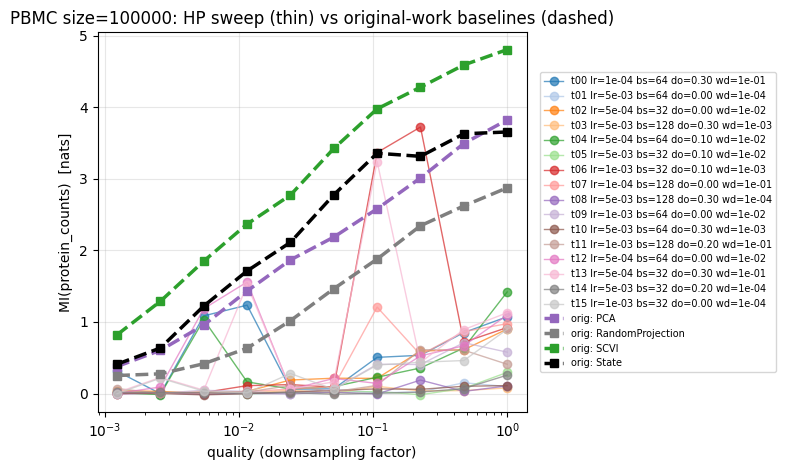

In [4]:
# Overlay: HP-sweep MI curves (one line per HP trial) + original-work baselines (one line per algorithm).
import matplotlib.pyplot as plt

mi_col = 'mi_protein_counts'
fig, ax = plt.subplots(figsize=(7.5, 4.8))

# --- HP sweep (from df / CURVES gathered above) ---
trial_ids = sorted(df['trial_id'].unique())
cmap = plt.get_cmap('tab20' if len(trial_ids) > 10 else 'tab10')
for i, tid in enumerate(trial_ids):
    sub = df[(df['trial_id'] == tid) & df[mi_col].notna()].sort_values('quality')
    if sub.empty:
        continue
    cfg = sub.iloc[0]
    label = (f"t{int(tid):02d} "
             f"lr={cfg['max_lr']:.0e} bs={int(cfg['batch_size'])} "
             f"do={cfg['dropout']:.2f} wd={cfg['weight_decay']:.0e}")
    ax.plot(sub['quality'].values, sub[mi_col].values,
            marker='o', linewidth=1.0, alpha=0.7,
            color=cmap(i % cmap.N), label=label)

# --- Original-work baselines: thicker, distinct colors, dashed ---
algo_colors = {
    'State':            'k',
    'Geneformer':       'tab:red',
    'SCVI':             'tab:green',
    'PCA':              'tab:purple',
    'RandomProjection': 'tab:gray',
}
for algo, sub in orig_df.groupby('algo'):
    sub = sub.sort_values('quality')
    ax.plot(sub['quality'].values, sub['mi'].values,
            marker='s', linewidth=2.5, linestyle='--',
            color=algo_colors.get(algo, None),
            label=f'orig: {algo}', zorder=5)

ax.set_xscale('log')
ax.set_xlabel('quality (downsampling factor)')
ax.set_ylabel(f'MI({ORIG_SIGNAL})  [nats]')
ax.set_title(f'PBMC size={ORIG_SIZE}: HP sweep (thin) vs original-work baselines (dashed)')
ax.grid(alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=7, ncol=1)
plt.tight_layout()
plt.show()

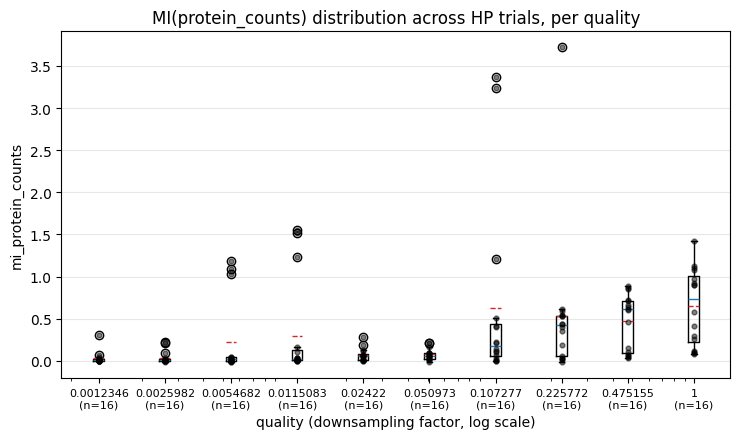

In [5]:
# Box plot: distribution of mi_protein_counts across HP trials, one box per quality.
# x-axis is true log scale (positions = quality, ax.set_xscale('log')).
import matplotlib.pyplot as plt
import numpy as np

mi_col = 'mi_protein_counts'
if mi_col not in df.columns:
    print(f'{mi_col} not found — nothing to plot.')
else:
    sub = df[df[mi_col].notna()]
    qualities = sorted(sub['quality'].unique())
    data = [sub.loc[sub['quality'] == q, mi_col].values for q in qualities]
    n_per = [len(d) for d in data]

    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    positions = np.array(qualities, dtype=float)
    # On a log axis, a constant linear `width` would look microscopic at small x
    # and huge at large x. Pick a constant log-space half-width (≈12%) and emit
    # asymmetric widths in linear units that map to it.
    w = 0.12
    widths = positions * (np.exp(w) - np.exp(-w)) / 2
    ax.boxplot(data, positions=positions, widths=widths,
               showmeans=True, meanline=True,
               medianprops=dict(color='C0'),
               meanprops=dict(color='C3', linestyle='--'))
    for pos, d in zip(positions, data):
        ax.scatter(np.full_like(d, pos, dtype=float), d,
                   s=12, alpha=0.5, color='k', zorder=3)

    ax.set_xscale('log')
    ax.set_xticks(positions)
    ax.set_xticklabels([f'{q:g}\n(n={n})' for q, n in zip(qualities, n_per)],
                       fontsize=8)
    ax.set_xlabel('quality (downsampling factor, log scale)')
    ax.set_ylabel('mi_protein_counts')
    ax.set_title('MI(protein_counts) distribution across HP trials, per quality')
    ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

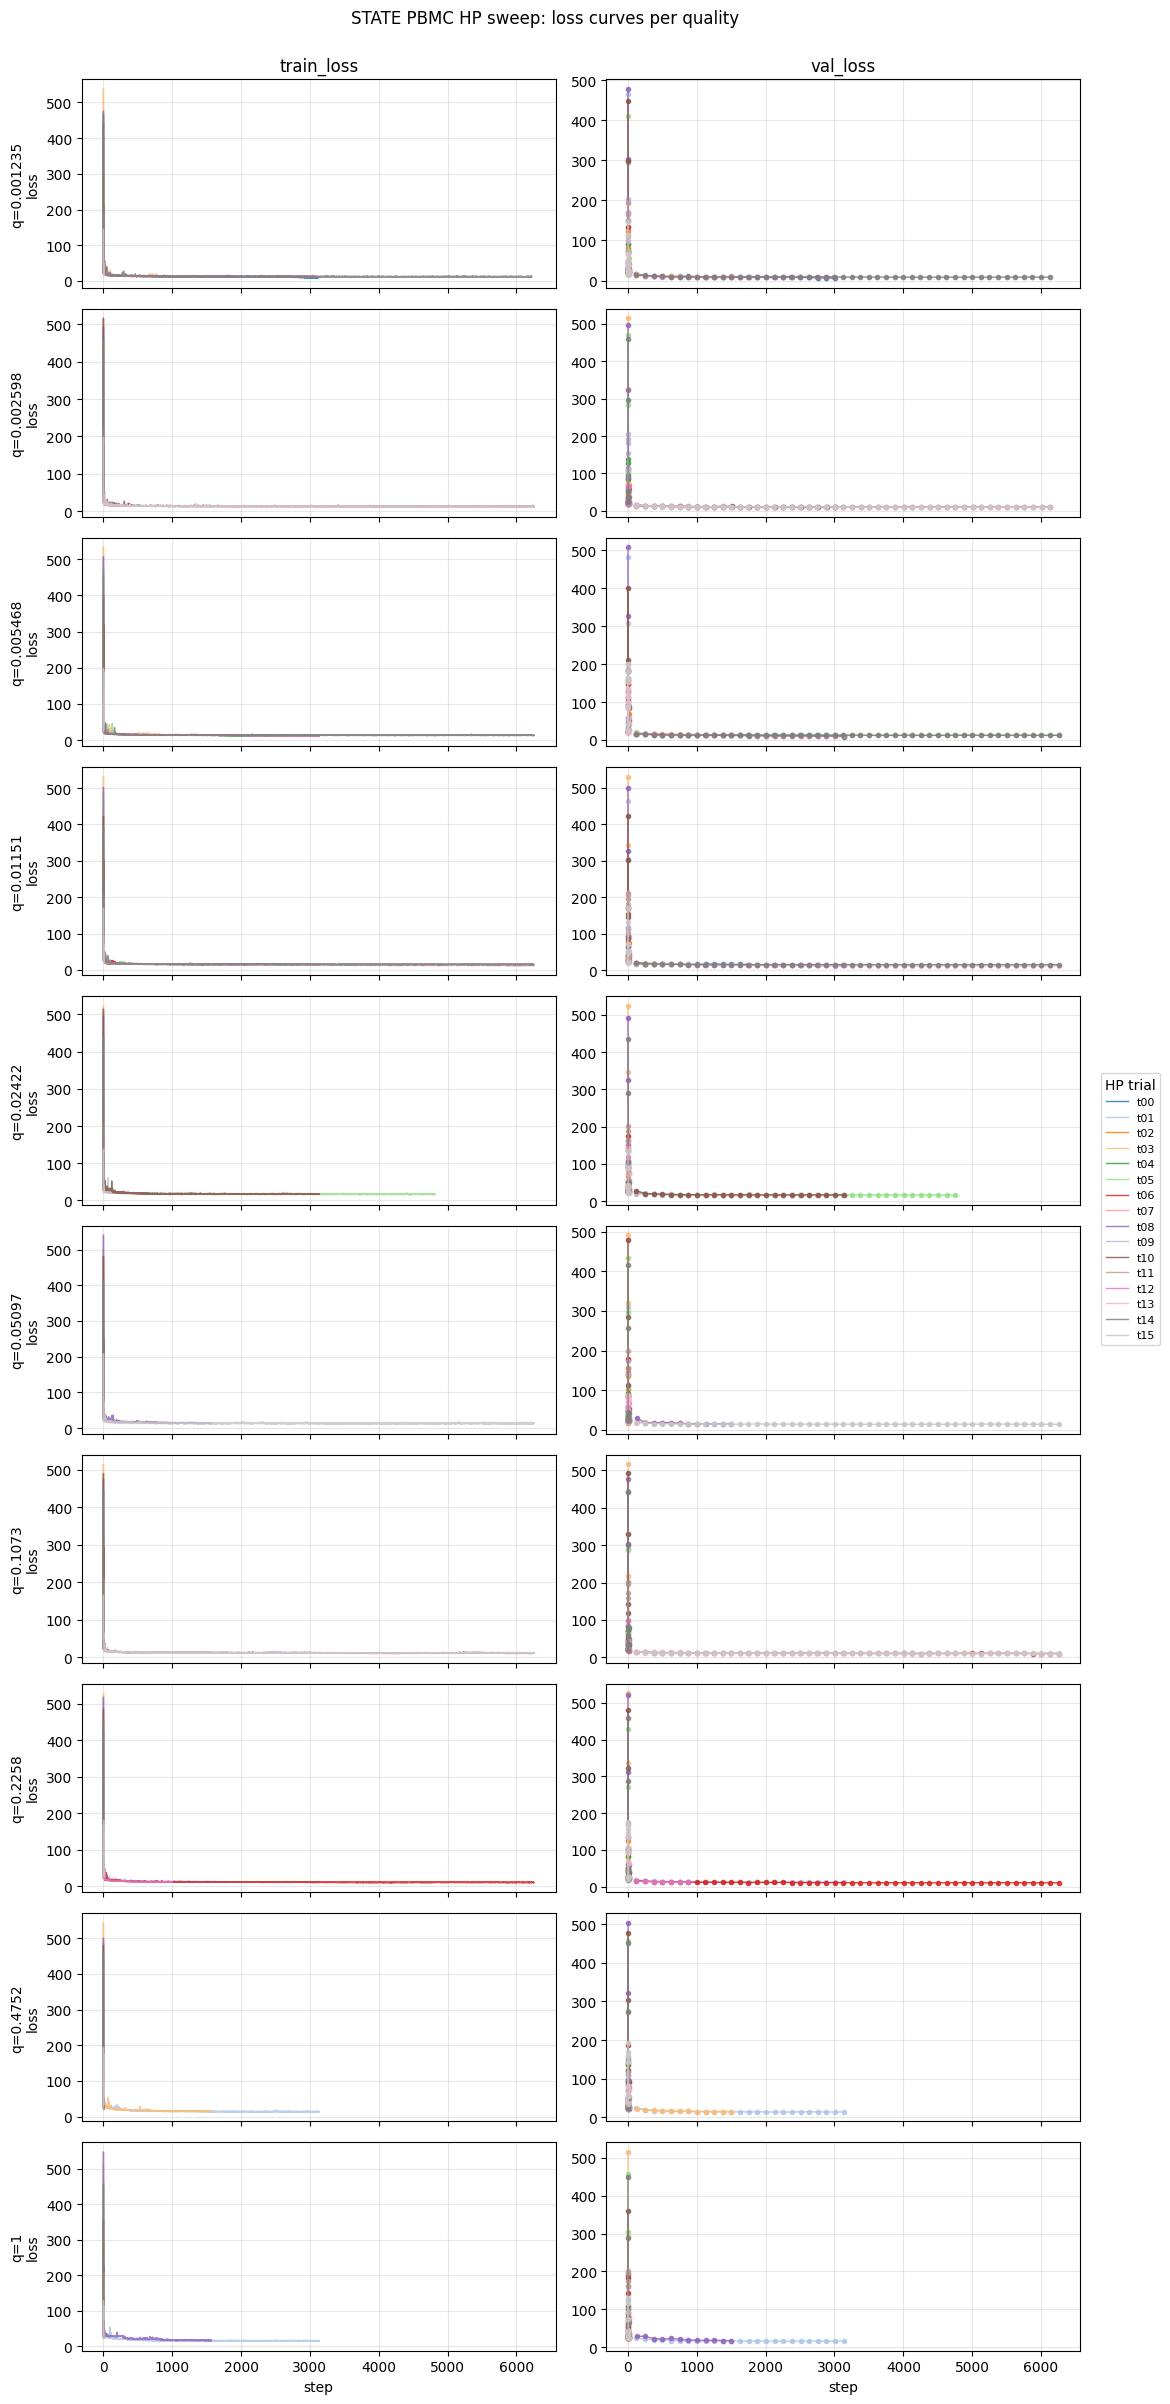

In [6]:
# Train / validation loss curves: 2 columns (train, val), 1 row per quality.
# Each subplot overlays one line per HP trial (using the curves stashed in CURVES).
import matplotlib.pyplot as plt
import numpy as np

qualities = sorted(df['quality'].unique())
trial_ids = sorted(df['trial_id'].unique())
cmap = plt.get_cmap('tab20' if len(trial_ids) > 10 else 'tab10')
trial_color = {tid: cmap(i % cmap.N) for i, tid in enumerate(trial_ids)}

n_rows = len(qualities)
fig, axes = plt.subplots(n_rows, 2, figsize=(11, 2.4 * n_rows),
                         sharex='col', squeeze=False)

for r, q in enumerate(qualities):
    ax_tr, ax_va = axes[r, 0], axes[r, 1]
    for tid in trial_ids:
        # CURVES is keyed (trial_id, size, quality); pick whichever size(s) exist for this trial+quality.
        keys = [k for k in CURVES if k[0] == tid and np.isclose(k[2], q)]
        for key in keys:
            curves = CURVES[key]
            tr, va = curves['train'], curves['val']
            color = trial_color[tid]
            if tr is not None and len(tr):
                ax_tr.plot(tr['step'].values, tr['train_loss'].values,
                           color=color, linewidth=1.0, alpha=0.85,
                           label=f't{tid:02d}' if r == 0 else None)
            if va is not None and len(va):
                ax_va.plot(va['step'].values, va['val_loss'].values,
                           color=color, linewidth=1.0, alpha=0.85, marker='o', markersize=3,
                           label=f't{tid:02d}' if r == 0 else None)
    ax_tr.set_ylabel(f'q={q:.4g}\nloss')
    ax_tr.grid(alpha=0.3)
    ax_va.grid(alpha=0.3)

axes[0, 0].set_title('train_loss')
axes[0, 1].set_title('val_loss')
axes[-1, 0].set_xlabel('step')
axes[-1, 1].set_xlabel('step')

# Single legend for the whole figure (HP trials).
handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
               fontsize=8, title='HP trial')
fig.suptitle('STATE PBMC HP sweep: loss curves per quality', y=1.0)
plt.tight_layout()
plt.show()